# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score
)

# Load Dataset

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning

In [3]:
# Drop if exists
df.drop("customerID", axis=1, inplace=True, errors='ignore')

# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values properly
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# EDA

## Target Variable Distribution

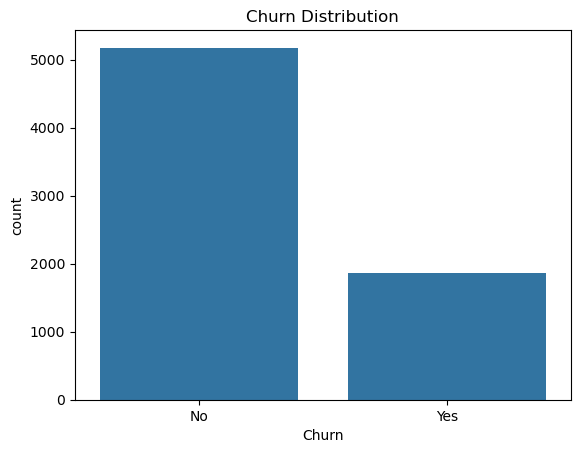

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

print(df["Churn"].value_counts(normalize=True) * 100)

## churn vs contract type

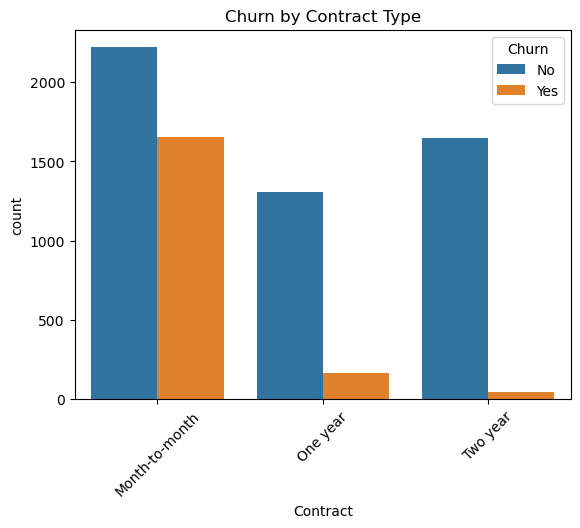

In [5]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

## churn vs tenure

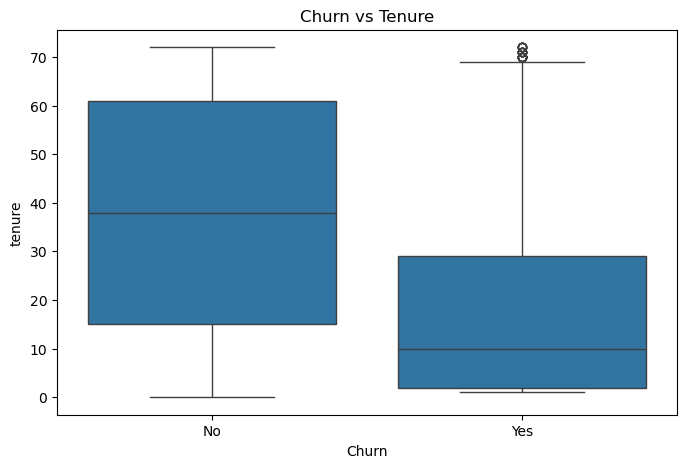

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Churn vs Tenure")
plt.show()

## churn vs monthly charges

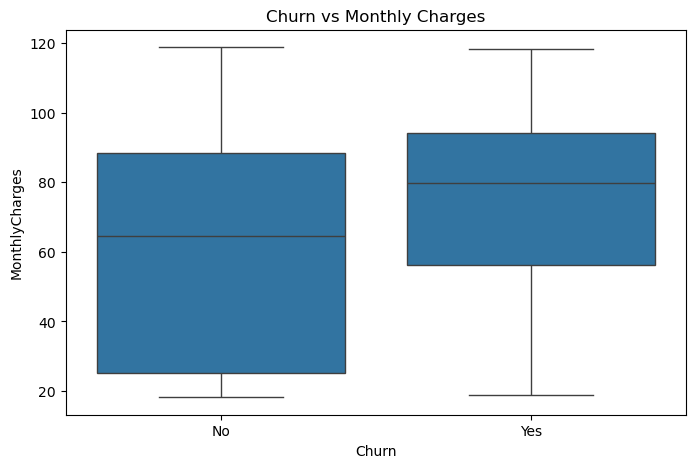

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Churn vs Monthly Charges")
plt.show()

## Correlation HeatMap After Encoding

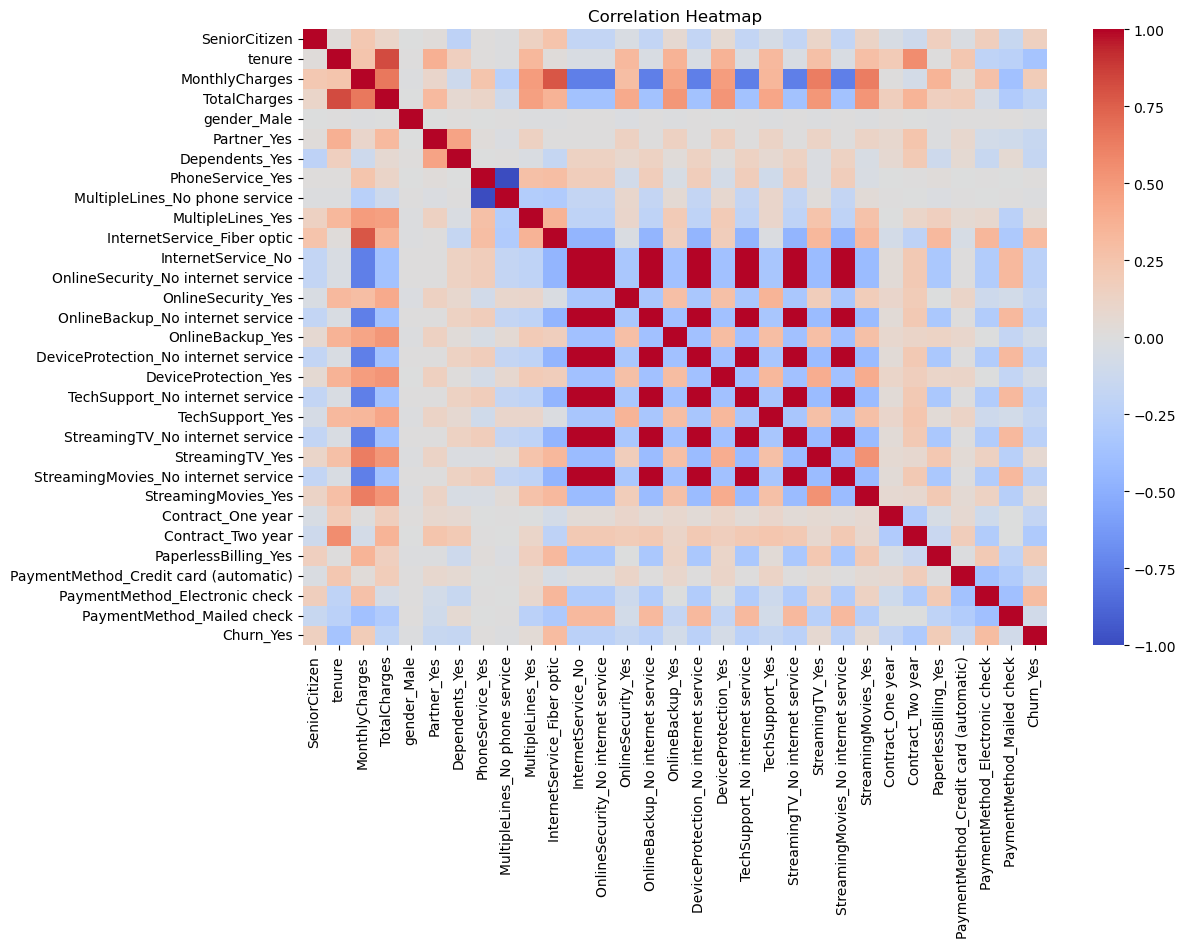

In [8]:
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Encode Categorical Variables

In [9]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


# Split The DataSet

In [10]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Baseline Model

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation

In [12]:
# print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7388218594748048
Balanced Accuracy: 0.7522100803430727
ROC-AUC: 0.8412333049161694

Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.72      0.80      1035
        True       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion Matrix:
 [[749 286]
 [ 82 292]]


# Random Forest  And HyperParamter Tuning

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define model
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# Parameter distribution
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Random Search
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


# Random Forest Predictions

In [14]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Random Forest Evaluations

In [15]:
print("===== Random Forest (Tuned) =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

===== Random Forest (Tuned) =====
Accuracy: 0.7650816181689141
Balanced Accuracy: 0.7675230566534914
ROC-AUC: 0.8441163553695523

Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.76      0.83      1035
        True       0.54      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409

Confusion Matrix:
 [[789 246]
 [ 85 289]]


# ROC CURVE COMPARISION

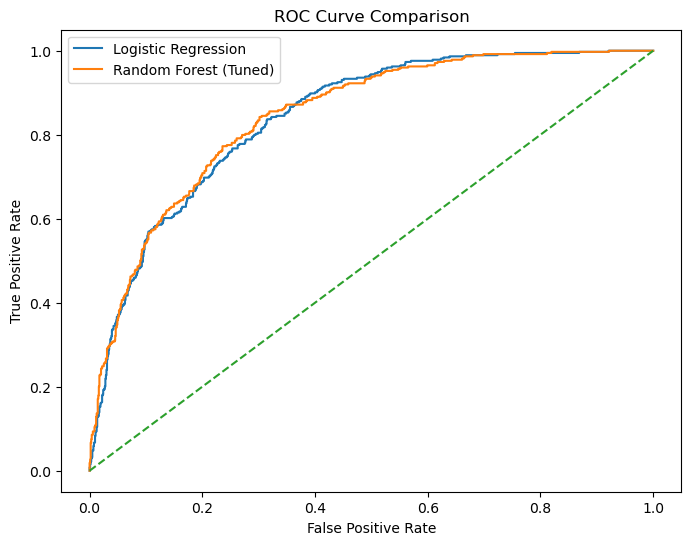

In [16]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (Tuned)")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Feature Importance

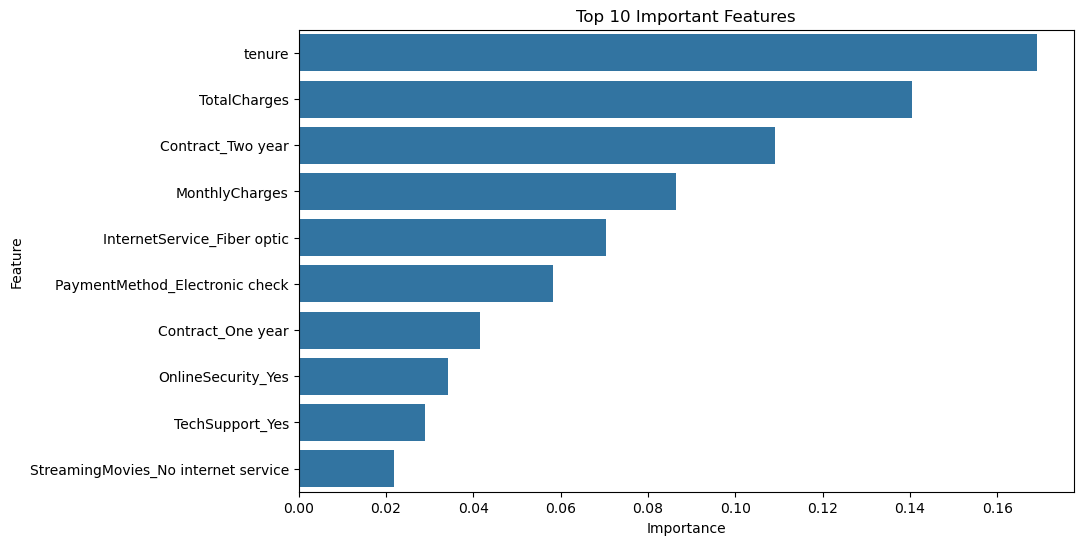

In [17]:
importances = best_rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

# Predicting a new customer

## Create a new Customer

In [21]:
import pandas as pd

new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.5],
    "TotalCharges": [400]
})

### Apply Same Preprocessing

In [22]:
X = pd.get_dummies(X, drop_first=True)

In [23]:
new_customer = pd.get_dummies(new_customer)
new_customer = new_customer.reindex(columns=X_train.columns, fill_value=0)

## Predict

In [24]:
prediction = best_rf.predict(new_customer)

result = "Yes – Customer is likely to churn!" if prediction[0] == 1 else "No – Customer is likely to stay."

print("Prediction Result")
print("=" * 50)
print(result)

Prediction Result
Yes – Customer is likely to churn!


# Model Comparision

In [18]:
print("=========== FINAL COMPARISON ===========")

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob_log))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

if roc_auc_score(y_test, y_prob_rf) > roc_auc_score(y_test, y_prob_log):
    print("\n🏆 Random Forest is the Best Model for Churn Prediction")
else:
    print("\n🏆 Logistic Regression Performs Better")

=========== FINAL COMPARISON ===========
Logistic Regression ROC-AUC: 0.8412333049161694
Random Forest ROC-AUC: 0.8441163553695523

🏆 Random Forest is the Best Model for Churn Prediction
